<a href="https://colab.research.google.com/github/smorgan-blip/lis4693/blob/main/lab-7/lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab-7 Sentiment Analysis

## Import Libraries

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

## Load Data

In [ ]:
import requests
import io

url = "https://raw.githubusercontent.com/smorgan-blip/lis4693/refs/heads/main/lab-5/bulgaria-md-export.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

df = pd.read_csv(io.StringIO(text))
print(df.head())

               Lens ID                                              Title  \
0  000-268-237-593-113  Combined Process of Chlorination Roasting and ...   
1  000-327-018-837-082  Two new species of Euscorpius (Scorpiones: Eus...   
2  000-338-901-308-378                                Occurrence Download   
3  000-444-464-368-194  Denial of access to sexual and reproductive he...   
4  000-601-743-028-48X  Potamophylax rilaensis sp. nov. (Trichoptera: ...   

   Publication Year Publication Type  \
0              2026  journal article   
1              2026          dataset   
2              2026          dataset   
3              2026  journal article   
4              2026          dataset   

                               Source Title  \
0            Materials (Basel, Switzerland)   
1                     The Catalogue of Life   
2  Global Biodiversity Information Facility   
3                       Reproductive health   
4                     The Catalogue of Life   

             

I choose the 'Abstract' field for my 'text' field in this lab.

In [ ]:
df = df.fillna('')

I had to add the code above because once again I would run into issues with Abstracts that were filled in with "NaN" because they were converted to floats

In [ ]:
print(df.head())

               Lens ID                                              Title  \
0  000-268-237-593-113  Combined Process of Chlorination Roasting and ...   
1  000-327-018-837-082  Two new species of Euscorpius (Scorpiones: Eus...   
2  000-338-901-308-378                                Occurrence Download   
3  000-444-464-368-194  Denial of access to sexual and reproductive he...   
4  000-601-743-028-48X  Potamophylax rilaensis sp. nov. (Trichoptera: ...   

   Publication Year Publication Type  \
0              2026  journal article   
1              2026          dataset   
2              2026          dataset   
3              2026  journal article   
4              2026          dataset   

                               Source Title  \
0            Materials (Basel, Switzerland)   
1                     The Catalogue of Life   
2  Global Biodiversity Information Facility   
3                       Reproductive health   
4                     The Catalogue of Life   

             

### Create new dataframe with "id" and "text" field.

In [ ]:
df_subset = df[['Lens ID', 'Abstract']].copy()

### Remove all non-alphabet characters

In [ ]:
df_subset['Abstract'] = df_subset['Abstract'].str.replace("[^a-zA-Z#]", "   ")

### Convert to Lower-case

In [ ]:
df_subset['Abstract'] = df_subset['Abstract'].str.casefold()
print(df_subset.head(10))

               Lens ID                                           Abstract
0  000-268-237-593-113  this study evaluates an integrated approach fo...
1  000-327-018-837-082                                                   
2  000-338-901-308-378  a dataset containing 5793745 species occurrenc...
3  000-444-464-368-194  in june 2021, the european parliament agreed t...
4  000-601-743-028-48X                                                   
5  000-854-416-487-369  a dataset containing 16231 species occurrences...
6  000-932-655-989-893                                                   
7  001-068-111-033-444  documentation in the barn on may 6 (st. george...
8  001-226-903-426-757  the illicit alcohol trading is a serious globa...
9  001-231-352-953-257  <jats:p>rotifers (rotifera) are microscopic ps...


## Generate Sentiment Polarity Scores

In [ ]:
df1 = pd.DataFrame()
df1['Lens ID'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

In [ ]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Abstract']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'Lens ID': row['Lens ID'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
                Lens ID sentiment_type  sentiment_score
3   000-268-237-593-113       compound           0.8591
7   000-327-018-837-082       compound           0.0000
11  000-338-901-308-378       compound           0.7845
15  000-444-464-368-194       compound           0.8720
19  000-601-743-028-48X       compound           0.0000
23  000-854-416-487-369       compound           0.8658
27  000-932-655-989-893       compound           0.0000
31  001-068-111-033-444       compound           0.0000
35  001-226-903-426-757       compound           0.9498
39  001-231-352-953-257       compound           0.9577


In [ ]:
df_output = pd.merge(df, t_df_cleaned, on='Lens ID', how='inner')
print(df_output.head(10))

               Lens ID                                              Title  \
0  000-268-237-593-113  Combined Process of Chlorination Roasting and ...   
1  000-327-018-837-082  Two new species of Euscorpius (Scorpiones: Eus...   
2  000-338-901-308-378                                Occurrence Download   
3  000-444-464-368-194  Denial of access to sexual and reproductive he...   
4  000-601-743-028-48X  Potamophylax rilaensis sp. nov. (Trichoptera: ...   
5  000-854-416-487-369                                Occurrence Download   
6  000-932-655-989-893  Advanced polyethersulfone membranes with silve...   
7  001-068-111-033-444                                     Sheep shearing   
8  001-226-903-426-757  Effect of Environmental Temperature and Humidi...   
9  001-231-352-953-257  New data on rotifers (Rotifera) from European ...   

   Publication Year Publication Type  \
0              2026  journal article   
1              2026          dataset   
2              2026          dat

Here I merged the sentiment back into our main dataframe, aligned with the Lens ID identifier field to coordinate correctly with each article

## Visualize Sentiment Analysis Output

In [ ]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,1000.000000
mean,0.266110
std,0.537133
min,-0.995200
25%,0.000000
50%,0.025800
75%,0.822500
max,0.997300


Above are the calculated sentiment statistics.

Looking at the min & max values we can see that there were articles nearly completely on both extremes. There was a min of -0.995 which indicates an strongly negative response and there was a max of 0.997 which indicates there was a slightly stronger positive response.

The mean averages the scores for all 1000 responses and that was a score of 0.266. That means that overall, there was a more positive reaction whether that was because the number of positive reviews outweighed the negative ones or because there were many highly positive reviews.

<Axes: title={'center': 'sentiment_score'}, xlabel='Source Country', ylabel='Mean Sentiment Score'>

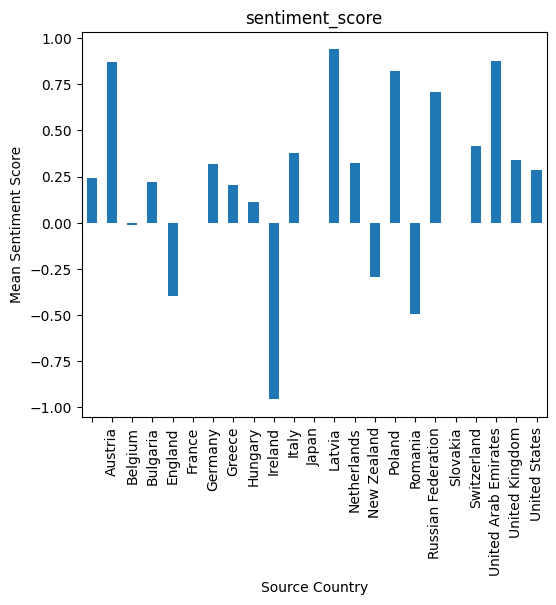

In [ ]:
dfg = df_output.groupby(['Source Country'])['sentiment_score'].mean()
dfg.plot(kind='bar', title='sentiment_score', ylabel='Mean Sentiment Score',
         xlabel='Source Country', figsize=(6, 5))

In the visualization above, the articles in the data set are grouped by their source country, and their average sentiment scores are shows in bars. I think this information was very interesting actually and enjoyed looking at the perspectives news outlets from different countries generally take. I think this could be a good indicator of attitudes on the topic in each culture or maybe current political relations.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, 'Switzerland'),
  Text(1, 0, ''),
  Text(2, 0, 'United Kingdom'),
  Text(3, 0, 'Netherlands'),
  Text(4, 0, 'United States'),
  Text(5, 0, 'Bulgaria'),
  Text(6, 0, 'Germany'),
  Text(7, 0, 'New Zealand'),
  Text(8, 0, 'United Arab Emirates'),
  Text(9, 0, 'England'),
  Text(10, 0, 'Ireland'),
  Text(11, 0, 'Russian Federation'),
  Text(12, 0, 'Hungary'),
  Text(13, 0, 'Austria'),
  Text(14, 0, 'Poland'),
  Text(15, 0, 'Greece'),
  Text(16, 0, 'Italy'),
  Text(17, 0, 'Latvia'),
  Text(18, 0, 'Romania'),
  Text(19, 0, 'France'),
  Text(20, 0, 'Japan'),
  Text(21, 0, 'Belgium'),
  Text(22, 0, 'Slovakia')])

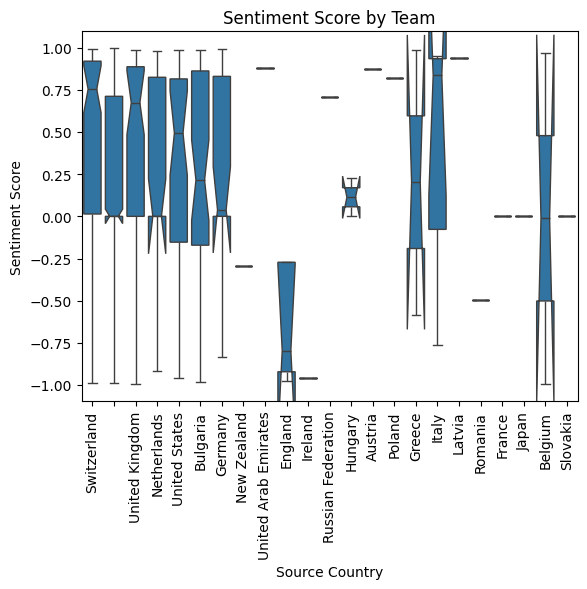

In [ ]:
import seaborn as sns
#create seaborn boxplots by group
sns.boxplot(x='Source Country', y='sentiment_score', notch = True,
            data=df_output, showfliers=False).set(title='Sentiment Score by Team')
#modify axis labels
plt.xlabel('Source Country')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=90)

This visualization comes from the seaborn visualization library and shows the same breakdown of sentiment scores of articles grouped by source country in a box plot this time. This chart includes the minimums, maximums, median, and distributions of the 1st-3rd quartile range. I like this chart because with the additional information we can see that many countries that might've been on one side (positive or negative) still had outliers on the other extreme. This tells us that these countries did not unanimously have an attitude and included many perspectives. Additionaly, for the few countries that did not have a wide distribution, we could see that there might've only been one article representing the country.

### Let's redo the graphs using the Atair Package

In [ ]:
import altair as alt

# Prepare data for mean sentiment score by province
dfg_province = df_output.groupby('Source Country')['sentiment_score'].mean().reset_index()

# Create the Altair bar chart for Sentiment Score by Province
chart_province = alt.Chart(dfg_province).mark_bar().encode(
    x=alt.X('Source Country:N', title='Country', sort='-y'), # Sort by sentiment score
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.Color('Source Country:N', legend=alt.Legend(title="Country")),
    tooltip=['Source Country', 'sentiment_score']
).properties(
    title='Mean Sentiment Score by Country'
).interactive()

chart_province

alt.Chart(...)

Here I used the Altair library to create the same bar chart visualization for my data. There are two main differences in this chart from the previous and they are that the Altair chart color codes the bars for easier identification and also orders them by score from positive to negative, left to right. For me, I think the color coding doesn't matter that much to me, although I believe with larger sets of categories it would be more useful for tracking. The ordering however, was very helpful because it allowed me to visually learn which countries were more positive or negative than others.

In [ ]:
pip install "vl-convert-python>=1.6.0"

In [ ]:
import altair as alt
alt.data_transformers.enable("vegafusion")

# Create the Altair box plot for Sentiment Score by Province
chart_boxplot = alt.Chart(df_output).mark_boxplot(extent='min-max', size=50).encode(
    x=alt.X('Source Country:N', title='Country', axis=alt.Axis(labels=False)), # Hide x-axis labels as they can overlap
    y=alt.Y('sentiment_score:Q', title='Sentiment Score'),
    color=alt.Color('Source Country:N', legend=alt.Legend(title="Country")),
    tooltip=['Source Country', 'sentiment_score']
).properties(
    title='Sentiment Score Distribution by Country'
).interactive()

chart_boxplot

alt.Chart(...)

This visualization is the Altair version of the previous Seaborn box plot. Like the bar chart we see that color coding is also included in this chart but the countries are not ordered by their average score. This chart allowed you to hover over each point to get more information like minimum and maximum but didn't do as good of a job as visually illustrating.

# Reflection

This lab was very interesting because I got to apply the sentiment analysis to a dataset I was interested in. When I first ran through the lab I was confused as to why my visualizations for sentiment over the years looked wrong but then I realized it was because all of the articles in my dataset were published in the same year, 2026. It was a little disappointing that I didn't get to see my data like that but I learned that it's important to understand your dataset to know what visualizations and what insights might be important. I very interested in seeing how the average responses from different countries varied because I felt it revealed a little bit about cultural attitudes or political relations and that could be useful in the future. My topic was the country Bulgaria, so having a field of information for each item that was relevant to the topic created greater insights. If I want to do any research in the future, I'll make sure to customize the dataset to include relevant fields so I can maximize the use of the functions of visualization.